# Übung 3

**Gruppenname:**

*TKKR*

Gehen Sie wie folgt vor:

1. Bitte benennen Sie jetzt dieses Jupyter Notebook um (z.B. über `File -> Rename`):

   Namensschema: `Gruppenname-X`. Ersetzen Sie "X" mit der oben angegebenen Nummer der Übung.

   - Beispiel 1: Team REZA bearbeitet Übung 2. Das Notebook heißt: REZA-2.
   - Beispiel 2: Sie sind keinem Team zugeordnet (nicht empfehlenswert) und bearbeiten Übung 2: Ihr Notebook heißt: Nachname-2.


2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Vergessen Sie dabei nicht, das Jupyter Notebook regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

## In dieser Übung ...

... werden wir unsere erste "Besichtigung" unseres ersten Machine Learning Projektes abschließen und die Begriffe Trainingsset und Testset einführen (Aufgabe 3.1). Danach werden wir uns noch einmal kurz auf konzeptioneller Ebene Gedanken um die Fähigkeiten des Perzeptrons machen (Aufgabe 3.2). In Aufgabe 3.3 werden Sie Out-of-Sample Fehler mithilfe eines Testsets abschätzen, und in Übung 3.4 sich noch einmal kurz mit dem Schwertliliendatensatz aus der letzten Übung beschäftigen.


## 3.1 Trainingsset und Testset
Stellen Sie sich vor, Sie arbeiten bei einem innovativen Medizingeräte-Hersteller für Röntgengeräte. Ihre Vorgesetzte stellt Ihnen die Aufgabe, ein Machine Learning Modell zu entwickeln, das anhand von Röntgenbildern der Lunge entscheiden soll, ob ein Patient Lungenkrebs hat oder nicht. Sie erhalten 4000 Röntgenbilder (features) samt Diagnose (labels: Krebs ja/nein).

Lassen Sie uns vereinfachend annehmen, dass Sie aus den Röntgenbildern features (Eigenschaften) extrahieren, und dass Sie ein Perzeptron darauf trainieren, zwischen Fällen mit Krebs und denen ohne Krebs zu unterscheiden.

Bearbeiten Sie folgende Aufgaben:

(1) Sie wählen eine zufällige Hypothese aus dem Hypothesenset des Perzeptrons aus und bestimmen den In-Sample Fehler $E_\text{in}$ auf dem Datensatz (alle 4000 Daten). Ihr Perzeptron wird dann in den Geräten des Herstellers eingesetzt. 

* Können Sie eine Aussage darüber treffen, wie groß der Vorhersagefehler (out-of-sample Fehler $E_\text{out}$) Ihres Perzeptrons für die neuen Patienten sein wird? Begründen Sie Ihre Antwort in wenigen Sätzen. (Tipp: Welche Hoeffding-Ungleichung aus der Vorlesung kann Ihnen hier helfen?) 

Da ich eine zufällige Hypothese wähle, gilt die Ungleichung $P(|E_{in} - E_{out}| > \epsilon)\leq 2e^{-2\epsilon^2N}$.

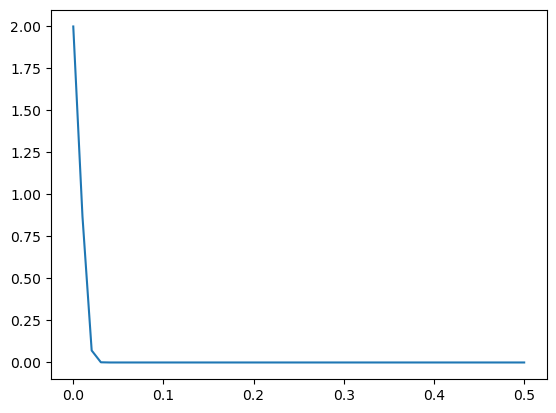

Die Wahrscheinlichkeit, dass E_out mehr als 0.02 von E_in abweicht ist kleiner als 0.08152440795673242


In [1]:
import numpy as np
import matplotlib.pyplot as plt

epss = np.linspace(0.0, 0.5)
plt.plot(epss, 2 * np.exp(-2 * epss ** 2 * 4000))
plt.show()
print(f"Die Wahrscheinlichkeit, dass E_out mehr als 0.02 von E_in abweicht ist kleiner als {2 * np.exp(-2 * 0.02 ** 2 * 4000)}")

Somit kann ich relativ genaue Aussagen über $E_{out}$ geben

(2) Nehmen wir an, dass Sie mit der Klassifikationsgenauigket des in Teilaufgabe (1) ausgewählten Perzeptron unzufrieden sind. Sie probieren weitere Hypothesen (Geraden) für Ihr Perzeptron aus. 

* Können Sie nun eine genauere Aussage darüber treffen, wie groß Ihr Vorhersagefehler für die zukünftigen Patienten sein wird? Begründen Sie in 1-2 Sätzen Ihre Antwort und nutzen Sie den Tipp aus der obigen Aufgabe.

Die Hoefding-Ungleichung muss jetzt um die Anzahl der Hypothesen erweitert werden, also $P(|E_{in} - E_{out}| > \epsilon)\leq 2 M e^{-2\epsilon^2N}$.

Je mehr Hypothesen, desto ungenauer wird die Aussage über $E_{out}$

(3) In einem echten Machine Learning Projekt würden Sie die Daten Ihrer Vorgesetzten entgegennehmen und in zwei Datensätze aufspalten: einem Trainingsset und einem Testset. Die prozentuale Aufteilung variiert je nach Projekt, aber typisch wäre 75% für das Trainingsset und 25% der Daten für das Testset. **Sie schließen die Daten im Testset weg und trainieren Ihr Perzeptron ausschließlich auf dem Trainingsset.** Nachdem das **Training auf dem Trainingsset** abgeschlossen ist, erhalten Sie Ihre finale Hypothese $g$, die Sie nun auf das Testset anwenden und dabei einen Klassifikationsfehler erhalten.

* Schlagen Sie die verschiedenen Hoeffding-Ungleichungen in der zweiten Vorlesung nach. Welche der Gleichungen gilt für das Trainingsset, welche für das Testset? 

Da das Trainingsset mehrere Hypothesen verwendet, gilt die Hoefding-Ungleichung $P(|E_{in} - E_{out}| > \epsilon)\leq 2 M e^{-2\epsilon^2N}$.

Für das Testset ist die Hypothese dann bereits ausgewählt, weshalb $P(|E_{in} - E_{out}| > \epsilon)\leq 2 e^{-2\epsilon^2N}$ gilt.

* Welchen Vorteil hat es, wenn Sie ein Testset verwenden, wenn Sie Ihrer Vorgesetzten eine möglichst präzise Vorhersage des Out-of-Sample Fehlers $E_\text{out}$ geben wollen? Begründen Sie Ihre Antwort in wenigen Sätzen.

Dadurch kann die Hoefding-Ungleichung mit M=1 gewählt werden was es viel einfacher mach über die Ungleichung einen Schätzer für E_out zu geben

* Welchen Nachteil hat Ihrer Meinung nach die Aufteilung der Daten in Trainingsset und Testset? Begründen Sie Ihre Antwort in wenigen Sätzen.

Der Parameter N wird sowohl im Trainings, als auch im Testset kleiner, wodurch die Funktion schlechter Approximiert und die Ungleichung mit kleineren epsilons durchgeführt werden muss

(4) Nehmen wir einmal an, dass Ihr Perzeptron auf den Röntgenbild-Daten zu viele Fehler macht, d.h. Ihre finale Hypothese $g$, die Sie über das Trainingsset erhalten haben, erzeugt einen großen Klassifikationsfehler auf dem Testset. Sie trainieren nun eine Anzahl $Q$ weiterer Machine Learning Methoden auf Ihrem Trainingsset, zum Beispiel k-Nearest Neighbors oder Support Vector Machines. Auch für diese Methoden erhalten Sie finale Hypothesen $g_1,\ldots,g_Q$, deren Klassifikationsfehler Sie auf Ihrem Testset berechnen. Sie wählen dann aus $g_1,\ldots,g_Q$ die Hypothese $g^*$, die den kleinsten Klassifikationsfehler auf dem Testset erzielt.

* Welche der Hoeffding-Ungleichungen aus der Vorlesung gilt nun für das Testset? Verbessert oder verschlechtert sich Ihre Fähigkeit, mithilfe eines Klassifikationsfehlers auf dem Testset den Out-of-Sample Fehler $E_\text{out}$ für $g^*$ vorherzusagen?

Es gilt wieder $P(|E_{in} - E_{out}| > \epsilon)\leq 2 M e^{-2\epsilon^2N}$. Die Fähigkeit $E_{out}$ vorherzusagen verschlechtert sich.

(5) Es ist nicht ungewöhnlich, mehrere Machine Learning Methoden für ein Machine Learning Projekt auszuprobieren. Angenommen Sie planen, mehrere Machine Learning Methoden auf Ihr Trainingsset anzusetzen, um damit mehrere finale Hypothesen $g_i$ zu erhalten, aus denen Sie dann mithilfe des Testsets die beste finale Hypothese $g^*$ auswählen: 
* Haben Sie eine Idee, wie Sie die Daten, die Sie in Teilaufgabe (3) aufgespalten haben, anders aufspalten könnten, um möglichst genau den Out-of-Sample Fehler $E_\text{out}$ für die Hypothese $g^*$ vorherzusagen? Begründen Sie in wenigen Sätzen Ihre Idee.

Man spaltet die Daten in ein Trainings-, ein Validierungs- und ein Testset auf. Das Validierungsset wird dann genutzt, um $g^*$ aus $g_i$ auszuwählen. Wenn $g^*$ ausgewählt wurde, kann man $E_{out}$ wieder anhand der Schranke $P(|E_{in} - E_{out}| > \epsilon)\leq 2 e^{-2\epsilon^2N}$ mit dem Testset bestimmen.

**Schlussbemerkung:** Wenn Sie viele Hypothesen auf demselben Datensatz testen, dann sprechen Machine Learning-Experten umgangssprachlich gerne von einer "Erschöpfung", einem "Verbrauch" oder auch einer "Beschmutzung" des Datensatzes. Sie wissen natürlich, dass das Umgangssprache ist, die Sie nicht in Prüfungen oder in anderen offiziellen Situationen nutzen.

## 3.2 Das Perzeptron und ein US-amerikanischer Sportartikelhersteller

Ein bekannter US-amerikanischer Sportartikelhersteller hat vor einigen Jahren festgestellt, dass er zwei Kundensegmente hat:

1. männliche Teenager
2. Ältere Frauen

Dieser Fall ist echt und ich habe ihn mir nicht ausgedacht. Was das für die Marketingstrategie des Herstellers bedeutet, lassen wir einmal beiseite.

Hier kommt der Teil, den ich mir für Sie ausgedacht habe:

Sie erhalten Features von Personen, nämlich (1.) Alter und (2.) Geschlecht. Das Feature "Alter" entspricht nicht dem Alter in Jahren, sondern unterscheidet nur zwischen den beiden Gruppen "Jung" und "Alt". Sie sollen mithilfe eines Perzeptrons (also eines Neurons) vorhersagen, ob die Person zum potenziellen Kunden des Herstellers zählt (Label +1) oder nicht (Label -1).

**Ihre Aufgaben**

(1) Nehmen Sie sich ein Blatt Papier und zeichnen Sie darauf ein Koordinatensystem: Die y-Achse sei die Achse, auf der das Alter aufgetragen ist. Die x-Achse sei die Achse, auf der das Geschlecht von Mann nach Frau aufgetragen ist. (Wir nehmen vereinfachend ein Kontinuum an Geschlechtern an, was dem Stand der aktuellen Geschlechterforschung auch eher entspricht.)

(2) Markieren Sie nun mit einer Farbe die Bereiche im Koordinatensystem, die zu den beiden obigen Kundensegmenten zählen. Markieren Sie dann mit einer anderen Farbe die Bereiche im Koordinatensystem, die **nicht** zu den beiden Kundensegmenten zählen.

(3) Betrachten Sie Ihr Koordinatensystem: Können Sie mithilfe eines Perzeptrons (also einer Gerade) die Kunden von den Nicht-Kunden trennen? Beschreiben Sie mit 1-3 Sätzen Ihre Beobachtung.

(4) Wenn Sie die Frage aus Teilaufgabe (3) verneint haben: Könnten Sie mit mehr als einem Perzeptron die Kunden von den Nicht-Kunden trennen? Falls ja, wie würden Sie dies bewerkstelligen? Beschreiben Sie Ihren Ansatz in 1-3 Sätzen.

**Schlussbemerkung:** Die Beobachtungen, die Sie gemacht haben, wurden in den 60er Jahren publiziert. Sie führten zum ersten großen Winter der KI-Forschung (KI: Künstliche Intelligenz), insbesondere für Forscherinnern und Forscher, die sich für künstliche Neuronen interessierten und damit der konnektionistischen Denkschule zuzuordnen waren: Für rund 15 Jahre brach die Finanzierung für konnektionistische Forschung, also Forschung an neuronalen Netzen ein, da man Schwierigkeiten hatte, die Idee, die Sie voraussichtlich bei Aufgabenschritt (4) formulierten, umzusetzen.

## 3.3 Trainieren und Testen
Sie haben in Aufgabe 3.1 bereits das Konzept des Trainingssets und des Testsets kennengelernt. Wir werden dieses Konzept auf unser Lernproblem von letzter Woche anwenden. 

Ich bitte Sie:

* Kopieren Sie Ihren Code für PLA und für das Perzeptron aus Ihrem alten Jupyter Notebook in dieses Jupyter Notebook.
* **Bevor Sie fortfahren,** hier noch ein Hinweis: Sollten Sie einmal aus Versehen eine Endlosschleife bauen und/oder Ihr Algorithmus terminiert nicht, dann wird das Schließen des Browserfensters den Rechenprozess (den Kernel) nicht stoppen. Er wird auf dem Server weiterlaufen. Stattdessen sollten Sie in diesem Fall den Kernel dieses *Jupyter Notebooks* stoppen durch das Menü `Kernel -> Interrupt` oder durch die Tastatur mit: `ESC` (Wechsel in den Command-Mode) und dann zweimal die Taste `i` drücken. Wenn Sie sich für weitere Informationen zu *Jupyter Notebook* interessieren, schauen Sie auch gerne im Tutorial im ILIAS Kurs (Übungsmodul) unter "Vorbereitungen, Aufgabe 1.1." nach.
* Vergessen Sie nicht, Ihr *Jupyter Notebook* ab und an zu speichern (mit der Tastenkombination `Strg` + `s`).

Unser Ziel ist es, den Vorhersagefehler, den Ihr trainiertes Perzeptron auf Daten macht, zu charakterisieren und zu quantifizieren.

**Ihre Aufgaben:**

(1) Betrachten Sie den unten angegebenen Code, der einen synthetischen Datensatz erzeugt. Adaptieren Sie diesen Code, sodass er Ihnen garantiert einen zufälligen Datensatz zurückliefert, der Punkte beider Labels enthält. (Als Hack könnten Sie `generate_decision_line` so oft aufrufen, bis Sie einen Datensatz erhalten, der Punkte beider Labels enthält (also mindestens einen Punkt mit einem Label und mindestens einen Punkt mit anderem Label.))

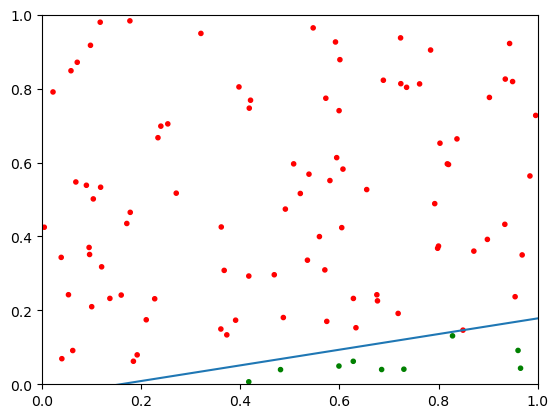

In [2]:
# Der folgende Code erzeugt Ihnen den synthetischen Datensatz, 
# mit dem Sie schon in der letzten Woche gearbeitet haben.
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

def generate_points(N):
    return np.random.rand(N, 2)
    
def generate_decision_line():
    g = generate_points(2)
    m = (g[1, 1]-g[1, 0])/(g[0, 1]-g[0, 0])
    b = g[1, 0]-m*g[0, 0]
    def getY(x):
        return m*x+b
    func = getY
    return func

def getClassedPoints(N):
    tf = generate_decision_line()  # target function
    X = generate_points(N)  # data set
    labels = np.array([1 if tf(X[i, 0]) > X[i, 1] else -1 for i in range(X.shape[0]) ])  # labels
    if np.unique(labels).shape[0] == 1:
        return getClassedPoints(N)
    return X, labels, tf

# obtain points p, targets t, and decision line g
X, y, target_function = getClassedPoints(100)

# create color labels according to target values
lookup = np.array(["r", "g"])
c = lookup[(y+1)//2]

# plot points
plt.axis((0, 1, 0, 1))
plt.scatter(X[:,0], X[:,1], c=c, marker='.')

# plot decision line
l = np.linspace(0, 1, 2)
plt.plot(l, target_function(l))
plt.show()

(2) Erzeugen Sie einen synthetischen Datensatz von 32 Datenpunkten.

In [3]:
X, y, target_function = getClassedPoints(32)

(3) Teilen Sie diesen Datensatz auf in ein Trainingsset (75%) und ein Testset (25%).

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

(4) Trainieren Sie ein Perzeptron mithilfe Ihres Perzeptron-Lern-Algorithmus von letzter Woche auf Ihrem Trainingsset und generieren Sie Ihre finale Hypothese $g$ (also die finale Gerade).

In [5]:
def h(x: np.ndarray, w: np.ndarray):
    return np.sign(x.dot(w))

def pla(X, y, w, verbose=False):
    X_stacked = np.hstack((np.ones(((X.shape[0], 1))), X))
    w_trace = []
    w_final = _pla_help(X_stacked, y, w, w_trace)
    if verbose:
        return w_final, w_trace
    return w_final

def _pla_help(X_stacked, y, w, w_trace):
    y_pred = h(X_stacked, w)
    bools = y_pred == y
    if np.all(bools):
        return w
    idx = np.argmin(bools)
    x_t = X_stacked[idx]
    y_t = y[idx]
    w_next = w + y_t * x_t
    w_trace.append(w_next)
    return _pla_help(X_stacked, y, w_next, w_trace)

In [6]:
w_final = pla(X_train, y_train, np.zeros(3,))

(5) Sei $N_1$ die Anzahl der Datenpunkte in Ihrem Trainingsset. Definieren Sie den Klassifikationsfehler wie folgt: 
$E_\text{in}(g) = \frac{1}{N_1}\sum_{i=1}^{N_1} [[g(\mathbf{x_i})\neq y_i)]]$, wobei $[[\cdot]]=1$ falls der Ausdruck $\cdot$ zutrifft; ansonsten ist $[[\cdot]]=0$.

* Berechnen Sie den Klassifikationsfehler auf dem Trainingsset. Welchen Wert erhalten Sie? Begründen Sie kurz, warum Sie genau diesen Klassifikationsfehler erhalten müssen. (Tipp: Wie arbeitet PLA?)

In [7]:
def error(X, y, g):
    n = X.shape[0]
    y_pred = g(X)
    return (y != y_pred).sum() / n

In [8]:
def get_g(w):
    def g(x):
        X_stacked = np.hstack((np.ones(((x.shape[0], 1))), x))
        return h(X_stacked, w)
    return g
print(f"Fehler auf den Trainingsdaten: {error(X_train, y_train, get_g(w_final))}")

Fehler auf den Trainingsdaten: 0.0


(6) Sei $N_2$ die Anzahl der Datenpunkte in Ihrem Testset. Definieren Sie den Klassifikationsfehler wie folgt: 
$E_\text{test}(g) = \frac{1}{N_2}\sum_{j=1}^{N_2} [[g(\mathbf{x_j})\neq y_j]]$, wobei $[[\cdot]]=1$ falls der Ausdruck $\cdot$ zutrifft; ansonsten ist $[[\cdot]]=0$.

 * Berechnen Sie den Klassifikationsfehler $E_\text{test}$ auf dem Testset. Dieser Fehler ist Ihr Anhaltspunkt, welchen Fehler $E_\text{out}$ Sie erwarten können.

In [9]:
print(f"Fehler auf den Testset: {error(X_test, y_test, get_g(w_final))}")

Fehler auf den Testset: 0.0


(7) Erzeugen Sie nun ein Ensemble von 100 Datensätzen (je 32 Datenpunkte), unterteilen Sie diese in Training- und Testsets (wie in den vorigen Schritten) und berechnen Sie den Mittelwert von $E_\text{test}$ über dieses Ensemble.

In [10]:
import sys

print("Aktuelle Grenze:", sys.getrecursionlimit())
sys.setrecursionlimit(30000) # Erhöht von 3000

Aktuelle Grenze: 3000


In [11]:
def get_avg_eout(test_size=0.25):
    E_outs = []
    for _ in range(100):
        X, y, _ = getClassedPoints(32)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)
        w_final = pla(X_train, y_train, np.zeros(3,))
        
        E_outs.append(error(X_test, y_test, get_g(w_final)))

    return np.average(E_outs)

get_avg_eout()

np.float64(0.05625)

(8) Wiederholen Sie Schritt 7, aber verkleinern Sie $N_1$ (und vergrößern Sie damit $N_2$) in Schritten von 4 (also: $N_1=24, 20, 16, \ldots,4$). Ermitteln Sie jeweils die Mittelwerte $E_\text{test}$. Zeichnen Sie in einer Abbildung den Mittelwert $E_\text{test}$ (y-Achse) gegen $N_1$ (x-Achse). Was beobachten Sie?

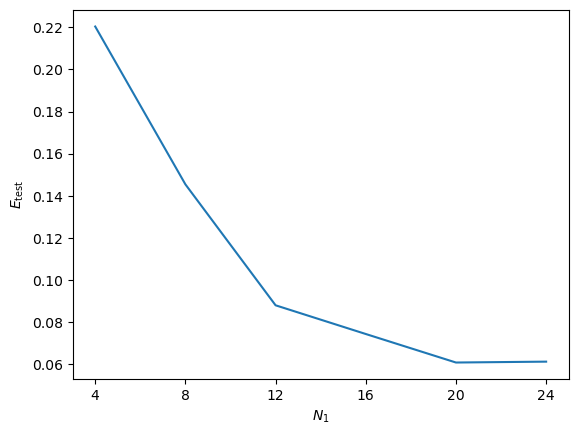

In [14]:
test_sizes = [0.25, 0.375, 0.5, 0.625, 0.75, 0.875]
e_out_avg = [get_avg_eout(size) for size in test_sizes]
n_1 = [32 * (1-size) for size in test_sizes]
plt.plot(n_1, e_out_avg)
plt.xticks(n_1)
plt.ylabel("$E_\\text{test}$")
plt.xlabel("$N_1$")
plt.show()

Je kleiner $N_1$, desto größer werden die Mittelwerte von $E_\text{test}$

(9) Erklären Sie Ihre Beobachtungen aus Schritt 8 (wenige Sätze) mithilfe der Hoeffding Ungleichung aus der Vorlesung. Vergegenwärtigen Sie sich dazu auch Ihre Überlegungen zu $E_\text{in}$ in Schritt 5. 

$$P(|E_{in} - E_{out}| > \epsilon)\leq 2 M e^{-2\epsilon^2N}$$
Dabei spielt $N$, also eine wichtige Rolle. Wenn beim Training $N$ verkleinert wird, kann nicht garantiert werden, dass das Epsilon klein wird.

## 3.4 Trainieren und Testen - Teil 2 (Optional)

Oft werden Trainingsset und Testset so definiert, dass die ersten 75% der Daten dem Trainingsset und die restlichen 25% der Daten dem Testset zugeschrieben werden. Schauen Sie in die alten Übungen nach und betrachten Sie dort den Schwertliliendatensatz.

**Ihre Aufgaben**

(1) Betrachten Sie die Labels des Schwertliliendatensatzes. Fällt Ihnen eine Besonderheit auf, wie die Daten in diesem Datensatz organisiert sind?

In [15]:
from sklearn.datasets import load_iris
data = load_iris()
data.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

Die labels sind sortiert.

(2) Was würde passieren, wenn Sie einfach die letzten 25% des Datensatzes als Testset nutzen würden? Welche Auswirkungen vermuten Sie?

Es würden nur Schwertlilien mit dem Label 2 getestet werden. $E_\text{test}$ wäre sehr hoch.

Das verletzt nämlich die Voraussetzung, dass die Feature-Wahrscheinlichkeit gleich beim Training, wie im Einsatz ist.

Das Modell wäre besonders auf Schwertlilien mit den Labels 0 und 1 trainiert und würde viele Fehler bei dem Label 2 machen.

(3) Wie würden Sie anstelle der in Punkt (2) vorgeschlagenen Aufteilung in Training- und Testset eine Aufteilung vornehmen?

Ich würde eine zufällige Auswahl der Daten durch [numpy.random.choice](https://numpy.org/doc/stable/reference/random/generated/numpy.random.choice.html) oder [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) verwenden.

Diese kleine Übung zeigt Ihnen einen typischen Fallstrick, der Ihnen bei echten Daten (also nicht synthetischen) häufig begegnet.